In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np
from pathlib import Path
import math

def calculate_grid_size(n):
    """Calculate the optimal grid size for n images using predefined layouts."""
    # 预定义常见数量的最优布局
    layouts = {
        # 1: (1, 1),
        # 2: (1, 2),
        # 3: (2, 2),
        # 4: (2, 2),
        # 5: (2, 3),
        # 6: (2, 3),
        # 7: (2, 4),
        # 8: (2, 4),
        # 9: (3, 3),
        # 10: (3, 4),
        # 11: (3, 4),
        # 12: (3, 4),
        # 可以继续添加更多...
        10: (4, 3),
        16: (6, 3),
    }
    
    # 如果数量在预定义布局中，直接返回
    if n in layouts:
        layout = layouts[n]
        print(f"Calculated grid size for {n} images: {layout}")
        return layout
    
    # 对于未预定义的数量，使用一个简单的计算方法
    rows = int(math.sqrt(n))
    cols = math.ceil(n / rows)
    layout = (rows, cols)
    # print(f"Calculated grid size for {n} images: {layout}")
    return layout

def load_image(path):
    """Load and convert image to numpy array."""
    img = Image.open(path)
    img = img.convert('RGB')
    return np.array(img)

def plot_comparison(folders_to_plot, image_name, compact_mode=False, figsize=(20, 12), dpi=300):
    """Plot comparison of same image from different folders."""
    n = len(folders_to_plot)
    rows, cols = calculate_grid_size(n)
    
    # 首先读取第一张图片来获取尺寸比例
    first_img = load_image(os.path.join(next(iter(folders_to_plot.values())), image_name))
    aspect_ratio = first_img.shape[1] / first_img.shape[0]  # 宽/高
    
    if compact_mode:
        # 根据图像比例调整figsize
        if figsize[0]/figsize[1] > (cols*aspect_ratio)/(rows):
            # 以高度为基准
            new_height = figsize[1]
            new_width = new_height * (cols*aspect_ratio)/rows
        else:
            # 以宽度为基准
            new_width = figsize[0]
            new_height = new_width * rows/(cols*aspect_ratio)
        
        fig = plt.figure(figsize=(new_width, new_height), frameon=False, dpi=dpi)
        gs = gridspec.GridSpec(rows, cols)
        gs.update(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    else:
        base_size = 5
        figsize = (base_size * cols, base_size * rows)
        fig = plt.figure(figsize=figsize, facecolor='white', dpi=dpi)
        gs = gridspec.GridSpec(rows, cols)
        gs.update(wspace=0.1, hspace=0.1)
    
    for idx, (folder_name, folder_path) in enumerate(folders_to_plot.items()):
        if idx < n:
            ax = plt.subplot(gs[idx])
            if folder_name == 'groundtruth':
                image_name = image_name.replace('LR', 'HR')
                image_name = image_name.replace('_gauss_subsample', '')
            img_path = os.path.join(folder_path, image_name)
            img = load_image(img_path)
            
            # 使用 'equal' 而不是 'auto' 来保持原始比例
            ax.imshow(img, aspect='equal')
            ax.axis('off')
            
            if not compact_mode:
                ax.set_title(folder_name, pad=5)
            
            if compact_mode:
                ax.set_position([
                    ax.get_position().x0,
                    ax.get_position().y0,
                    ax.get_position().width,
                    ax.get_position().height
                ])
    
    if not compact_mode:
        plt.tight_layout()
    
    return fig

def plot_all_comparisons(folders_to_plot, save_dir=None, compact_mode=False):
    """Plot comparisons for all images."""
    original_folder = folders_to_plot['input']
    image_files = [f for f in os.listdir(original_folder) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    total_images = len(image_files)
    for idx, img_name in enumerate(image_files, 1):
        print(f"Processing image {idx}/{total_images}: {img_name}")
        fig = plot_comparison(folders_to_plot, img_name, compact_mode=compact_mode)
        
        if save_dir:
            mode_suffix = '_compact' if compact_mode else '_annotated'
            save_path = os.path.join(save_dir, f'comparison{mode_suffix}_{img_name}')
            Path(save_dir).mkdir(parents=True, exist_ok=True)
            
            if compact_mode:
                # 紧凑模式：完全无边距保存
                fig.savefig(save_path, 
                          bbox_inches='tight',
                          pad_inches=0,
                          facecolor='none',
                          transparent=True)
            else:
                fig.savefig(save_path, 
                          bbox_inches='tight',
                          facecolor='white')
            plt.close(fig)
        else:
            plt.show()

/tmp/ipykernel_2908719/291663160.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


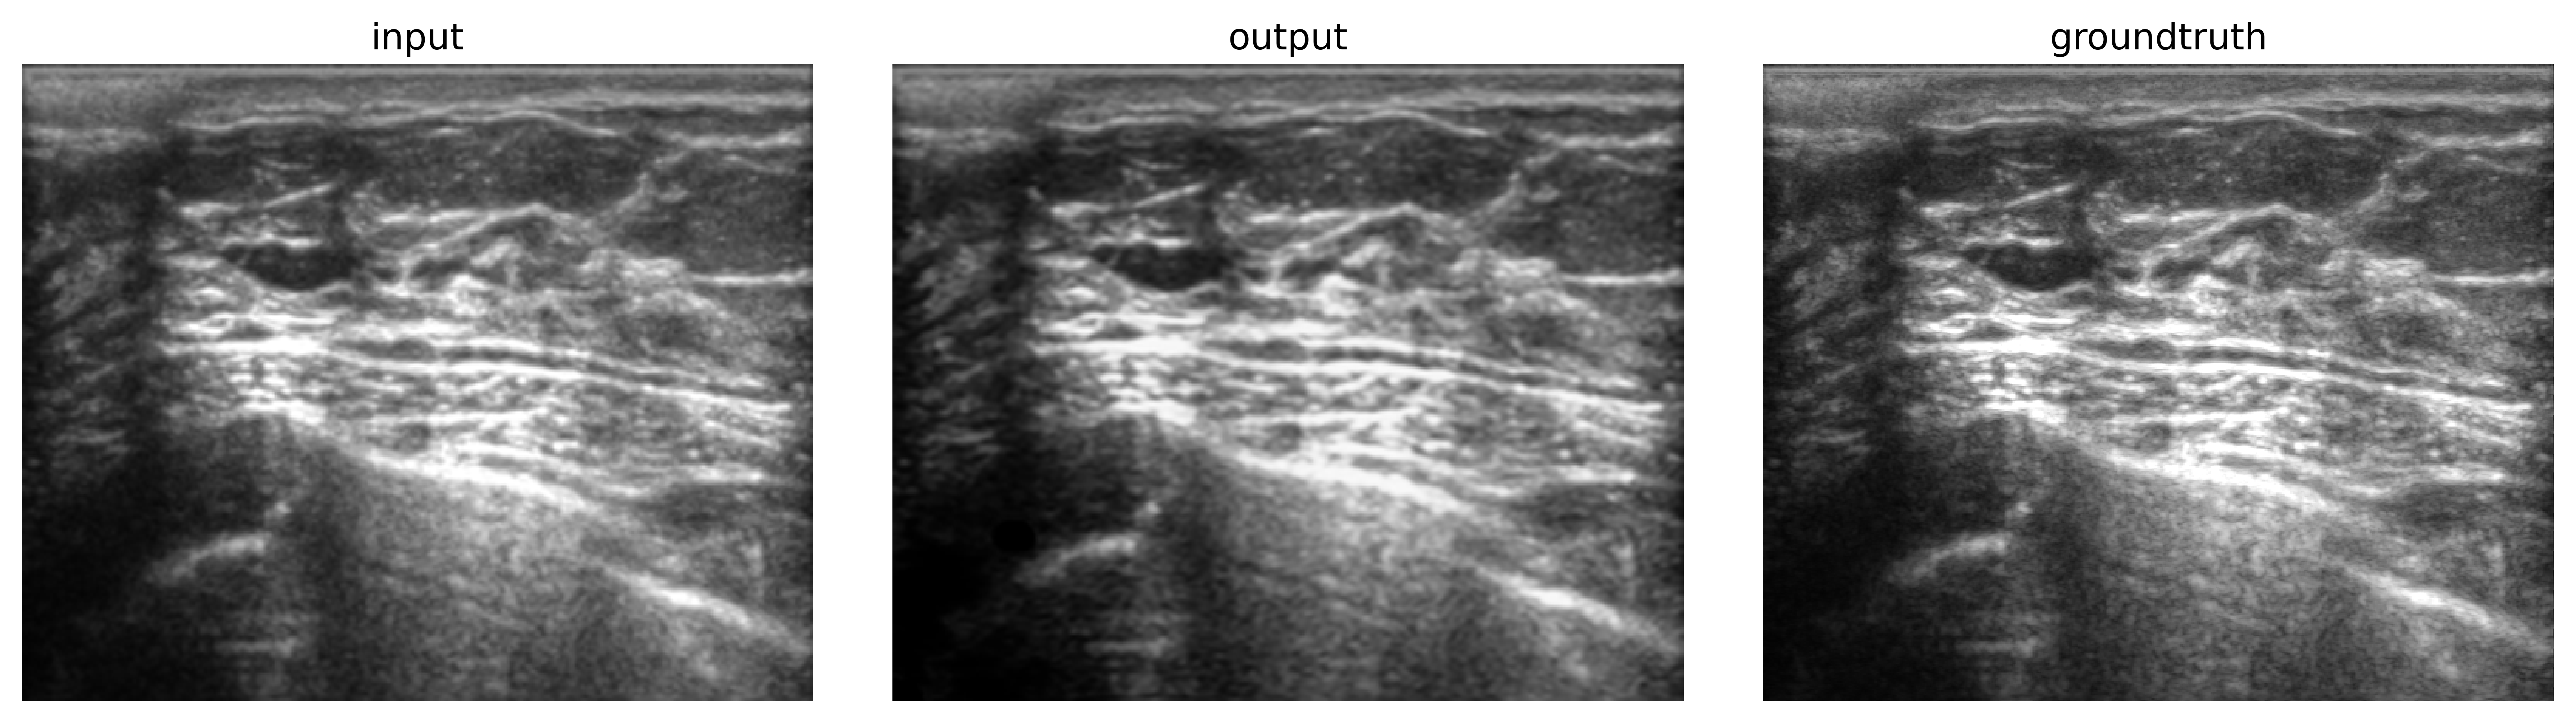

In [31]:
base_path = "/root/Lecter/cyclegan-exp/us-hand-to-large"

# folders_to_plot = {
#     'original': os.path.join(base_path, 'datasets/all/test'),
#     'resnet_9block': os.path.join(base_path, 'results/test_1.resnet_9block_a401_x4'),
#     # # 'unet256_resize': os.path.join(base_path, 'results/test_2.raw_unet256_resize_256_3090'),
#     'unet_256': os.path.join(base_path, 'results/test_2.unet_256_3090_x256'),
#     # # 'hybrid_restormer': os.path.join(base_path, 'results/test_xxx.hybrid_restormer_1'),
#     # 'vq_resnet_3090_max256': os.path.join(base_path, 'results/test_3.vq_resnet_3090_x4_max256'),
#     # 'vq_resnet_3090_max512': os.path.join(base_path, 'results/test_3.vq_resnet_3090_x4_max512'),
#     # 'vq_resnet_3090_max1024': os.path.join(base_path, 'results/test_3.vq_resnet_3090_x4_max1024'),
#     # 'vq_resnet_patch256_overlap32': os.path.join(base_path, 'results/test_patch256_overlap32'),
#     # 'vq_resnet_patch256_overlap64': os.path.join(base_path, 'results/test_patch256_overlap64'),
#     # 'vq_resnet_patch256_overlap128': os.path.join(base_path, 'results/test_patch256_overlap128'),
#     # 'vq_resnet_patch512_overlap64': os.path.join(base_path, 'results/test_patch512_overlap64'),
#     # 'vq_resnet_patch512_overlap128': os.path.join(base_path, 'results/test_patch512_overlap128'),
#     # 'vq_resnet_patch512_overlap256': os.path.join(base_path, 'results/test_patch512_overlap256'),
#     'vq_resnet_a6000_epoch185_max256': os.path.join(base_path, 'results/test_3.vq_resnet_a6000_epoch185_x4_max256'),
#     'vq_resnet_a6000_epoch185_max512': os.path.join(base_path, 'results/test_3.vq_resnet_a6000_epoch185_x4_max512'),
#     'vq_resnet_a6000_epoch185_max1024': os.path.join(base_path, 'results/test_3.vq_resnet_a6000_epoch185_x4_max1024'),
#     'vq_resnet_concat_paired_max256': os.path.join(base_path, 'results/test_grayscale_x4_max256'),
#     'vq_resnet_concat_paired_max512': os.path.join(base_path, 'results/test_grayscale_x4_max512'),
#     'vq_resnet_concat_paired_max1024': os.path.join(base_path, 'results/test_grayscale_x4_max1024'),
#     'vq_hybrid_restormer': os.path.join(base_path, 'results/test_xxx.hybrid_restormer_1'),
# }

# folders_to_plot = {  # gt
#     'input': os.path.join(base_path, 'datasets/split/test/test_semi_paired_LR'),
#     'output': "/root/Lecter/cyclegan-exp/us-hand-to-large/results/results_semi_paired/test_6.vq_resnet_v1_semi_un_paired_x4max256",
#     'groundtruth': os.path.join(base_path, 'datasets/split/test/test_semi_paired_HR'),
# }

# folders_to_plot = {
#     'input': os.path.join(base_path, 'datasets/split/test/test_only_LR'),
#     # 'resnet_9block': os.path.join(base_path, 'results/test_1.resnet_9block_a401_x4'),
#     # 'unet_256': os.path.join(base_path, 'results/test_2.unet_256_3090_x256'),
#     'output': "/root/Lecter/cyclegan-exp/us-hand-to-large/results/results_semi_paired/test_6.vq_resnet_v1_semi_un_paired_onlyLR_x4max256",
# }

folders_to_plot = {  # 张博
    'input': "/root/Lecter/dcm-convert/sort/origin/t1090000101al-dir_shrink2",
    'output': "/root/Lecter/cyclegan-exp/us-hand-to-large/results/zhang/test_t1_shrink2_20250319",
    'groundtruth': "/root/Lecter/dcm-convert/sort/origin/t1090000101al-dir",
}

# 使用示例
# 定义保存目录（可选）
# 绘制所有比较图
# save_dir = os.path.join(base_path, 'results/comparisons/comparisons_0317_zhang_t1/label')
# plot_all_comparisons(folders_to_plot, save_dir, compact_mode=False)

# 如果只想查看单张图片的比较
image_files = [f for f in os.listdir(folders_to_plot['input']) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_name = image_files[300]  # 读取列表中的第一张图片
plot_comparison(folders_to_plot, image_name, compact_mode=False, dpi=600)
plt.show()